# Halftone

Residual stream vectors from GPT-2 small are projected into 2D and translated into halftone fields. Each halftone mark is a sampled point in the normalized 2D projection space. Its size and orientation are derived from (nearby) GPT-2 residual stream points.

## Modes

### PCA Jump Mode (v1)

Residual stream vectors are reduced with PCA and normalized into a 2D plotting space. In the trajectory plot, dot size represents normalized layer-to-layer movement in the projected space. In the halftone image, dot size is generated from the nearby projected residual stream points and their layer-to-layer movement values.

### UMAP Density Mode

Residual stream vectors are reduced with UMAP and normalized into a 2D plotting space. In the trajectory plot, dot size is kept constant. In the halftone image, dot size represents local density of nearby projected residual stream points.

### PCA Jump Direction Mode (v2)

Residual stream vectors are reduced with PCA and normalized into a 2D plotting space. Dot size represents nearby layer-to-layer movement magnitude, and ellipse orientation follows the distance-weighted local tangent direction of nearby token trajectories.

In [1]:
!pip install transformer_lens umap-learn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 977.7/977.7 kB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 88.9 MB/s eta 0:00:00
  Created wheel for transformers-stream-generator: filename=transformers_stream_generator-0.0.5-py3-none-any.whl size=12426 sha256=aecf61e339a128f51ea2280e0012010feb02ef649f10fdb1522bff5e9091b587
  Stored in directory: /root/.cache/pip/wheels/a8/58/d2/014cb67c3cc6def738c1b1635dbf4e3dab6fb63aba7070dce0
Successfully built transformers-stream-generator
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [2]:
from transformer_lens import HookedTransformer
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
import umap
import torch
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

model = HookedTransformer.from_pretrained("gpt2-small")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Loaded pretrained model gpt2-small into HookedTransformer


In [3]:
def get_residual_points(text: str) -> dict:
    tokens = model.to_str_tokens(text)

    with torch.no_grad():
        _, cache = model.run_with_cache(text)

    points = []

    for layer in range(model.cfg.n_layers):
        residuals = cache["resid_post", layer][0]

        for token_index, token_str in enumerate(tokens):
            if token_str == "<|endoftext|>":
                continue

            points.append({
                "token_index": token_index,
                "token_str": token_str,
                "layer": layer,
                "embedding": residuals[token_index].tolist()
            })

    return {
        "tokens": [t for t in tokens if t != "<|endoftext|>"],
        "points": points
    }

In [4]:
def reduce_points_pca(residual_data: dict) -> dict:
    embeddings = np.array([
        point["embedding"] for point in residual_data["points"]
    ])

    pca = PCA(n_components=2)
    coords = pca.fit_transform(embeddings)

    points = []

    for point, coord in zip(residual_data["points"], coords):
        points.append({
            "token_index": point["token_index"],
            "token_str": point["token_str"],
            "layer": point["layer"],
            "x": float(coord[0]),
            "y": float(coord[1])
        })

    return {
        "tokens": residual_data["tokens"],
        "points": points,
        "explained_variance": pca.explained_variance_ratio_.tolist()
    }

In [5]:
def reduce_points_umap(residual_data: dict) -> dict:
    embeddings = np.array([
        point["embedding"] for point in residual_data["points"]
    ])

    reducer = umap.UMAP(n_components=2, random_state=42)
    coords = reducer.fit_transform(embeddings)

    points = []

    for point, coord in zip(residual_data["points"], coords):
        points.append({
            "token_index": point["token_index"],
            "token_str": point["token_str"],
            "layer": point["layer"],
            "x": float(coord[0]),
            "y": float(coord[1])
        })

    return {
        "tokens": residual_data["tokens"],
        "points": points
    }

In [6]:
def normalize_points(data: dict) -> dict:
    xs = np.array([point["x"] for point in data["points"]])
    ys = np.array([point["y"] for point in data["points"]])

    min_x, max_x = xs.min(), xs.max()
    min_y, max_y = ys.min(), ys.max()

    range_x = max_x - min_x or 1
    range_y = max_y - min_y or 1

    points = []

    for point in data["points"]:
        points.append({
            **point,
            "x": float((point["x"] - min_x) / range_x),
            "y": float((point["y"] - min_y) / range_y)
        })

    result = {
        "tokens": data["tokens"],
        "points": points
    }

    if "explained_variance" in data:
        result["explained_variance"] = data["explained_variance"]

    return result

In [7]:
def add_layer_jumps(norm_data: dict) -> dict:
    lookup = {
        (point["token_index"], point["layer"]): point
        for point in norm_data["points"]
    }

    raw_jumps = []

    for point in norm_data["points"]:
        if point["layer"] == 0:
            raw_jumps.append(0.0)
            continue

        prev = lookup.get((point["token_index"], point["layer"] - 1))

        if prev is None:
            raw_jumps.append(0.0)
        else:
            dx = point["x"] - prev["x"]
            dy = point["y"] - prev["y"]
            raw_jumps.append(float(np.sqrt(dx ** 2 + dy ** 2)))

    raw_jumps = np.array(raw_jumps)
    jump_range = raw_jumps.max() - raw_jumps.min() or 1

    points = []

    for point, raw_jump in zip(norm_data["points"], raw_jumps):
        points.append({
            **point,
            "jump": float((raw_jump - raw_jumps.min()) / jump_range),
            "raw_jump": float(raw_jump)
        })

    result = {
        "tokens": norm_data["tokens"],
        "points": points
    }

    if "explained_variance" in norm_data:
        result["explained_variance"] = norm_data["explained_variance"]

    return result

In [8]:
def add_point_density(norm_data: dict, bandwidth: float = 0.08) -> dict:
    coords = np.array([
        [point["x"], point["y"]]
        for point in norm_data["points"]
    ])

    densities = []

    for coord in coords:
        dist_sq = np.sum((coords - coord) ** 2, axis=1)
        density = np.sum(np.exp(-dist_sq / (2 * bandwidth ** 2)))
        densities.append(density)

    densities = np.array(densities)
    density_range = densities.max() - densities.min() or 1

    points = []

    for point, density in zip(norm_data["points"], densities):
        points.append({
            **point,
            "density": float((density - densities.min()) / density_range),
            "raw_density": float(density)
        })

    return {
        "tokens": norm_data["tokens"],
        "points": points
    }

In [9]:
def process_text(text: str) -> tuple[dict, dict]:
    residual_data = get_residual_points(text)

    pca_data = reduce_points_pca(residual_data)
    umap_data = reduce_points_umap(residual_data)

    pca_norm = normalize_points(pca_data)
    umap_norm = normalize_points(umap_data)

    pca_jump = add_layer_jumps(pca_norm)
    umap_density = add_point_density(umap_norm)

    print("tokens:", len(residual_data["tokens"]))
    print("points:", len(residual_data["points"]))
    print("PCA explained variance:", pca_data["explained_variance"])

    return pca_jump, umap_density

In [10]:
def render_trajectory_plot(
    data: dict,
    title: str = "",
    size_key: str | None = None
):
    token_indices = sorted(set(
        point["token_index"] for point in data["points"]
    ))

    plt.figure(figsize=(8, 8))

    for token_index in token_indices:
        token_points = [
            point for point in data["points"]
            if point["token_index"] == token_index
        ]

        token_points = sorted(token_points, key=lambda point: point["layer"])

        xs = [point["x"] for point in token_points]
        ys = [point["y"] for point in token_points]

        if size_key is None:
            sizes = 20
        else:
            sizes = [
                10 + (point.get(size_key, 0) ** 0.5) * 80
                for point in token_points
            ]

        plt.plot(xs, ys, linewidth=0.8, alpha=0.45)
        plt.scatter(xs, ys, s=sizes, alpha=0.75, linewidths=0)

    if title:
        plt.title(title, fontsize=14)

    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(alpha=0.18)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.tight_layout()
    plt.show()

In [11]:
def render_reference_plots(pca_jump: dict, umap_density: dict):
    render_trajectory_plot(
        pca_jump,
        title="PCA Token Trajectory Plot",
        size_key="jump"
    )

    render_trajectory_plot(
        umap_density,
        title="UMAP Token Trajectory Plot"
    )

In [12]:
def render_halftone_field(
    data: dict,
    title: str = "",
    weight_key: str | None = None,
    grid_n: int = 120,
    influence: float = 0.035,
    min_size: float = 0.4,
    max_size: float = 28,
    power: float = 1.1
):
    coords = np.array([
        [point["x"], point["y"]]
        for point in data["points"]
    ])

    if weight_key is None:
        weights = None
    else:
        weights = np.array([
            point.get(weight_key, 0.0)
            for point in data["points"]
        ])

    grid = np.linspace(0, 1, grid_n)

    dot_x = []
    dot_y = []
    dot_tone = []

    for x in grid:
        for y in grid:
            dist_sq = np.sum((coords - np.array([x, y])) ** 2, axis=1)
            kernel = np.exp(-dist_sq / (2 * influence ** 2))

            if weights is None:
                tone = np.sum(kernel)
            else:
                tone = np.sum(weights * kernel) / (np.sum(kernel) + 1e-8)

            dot_x.append(x)
            dot_y.append(y)
            dot_tone.append(tone)

    dot_tone = np.array(dot_tone)
    dot_tone = dot_tone / (dot_tone.max() or 1)

    sizes = min_size + (dot_tone ** power) * max_size

    plt.figure(figsize=(8, 8))
    plt.scatter(
        dot_x,
        dot_y,
        s=sizes,
        c="black",
        alpha=0.9,
        linewidths=0
    )

    if title:
        plt.title(title, fontsize=14)

    plt.axis("off")
    plt.gca().set_aspect("equal", adjustable="box")
    plt.tight_layout()
    plt.show()

In [13]:
text = "in Just- spring when the world is mud- luscious the little lame balloonman whistles far and wee and eddieandbill come running from marbles and piracies and it's spring when the world is puddle-wonderful the queer old balloonman whistles far and wee and bettyandisbel come dancing from hop-scotch and jump-rope and it's spring and the goat-footed balloonMan whistles far and wee"

pca_jump, umap_density = process_text(text)

tokens: 95
points: 1140
PCA explained variance: [0.7064377614277862, 0.04771561334026873]


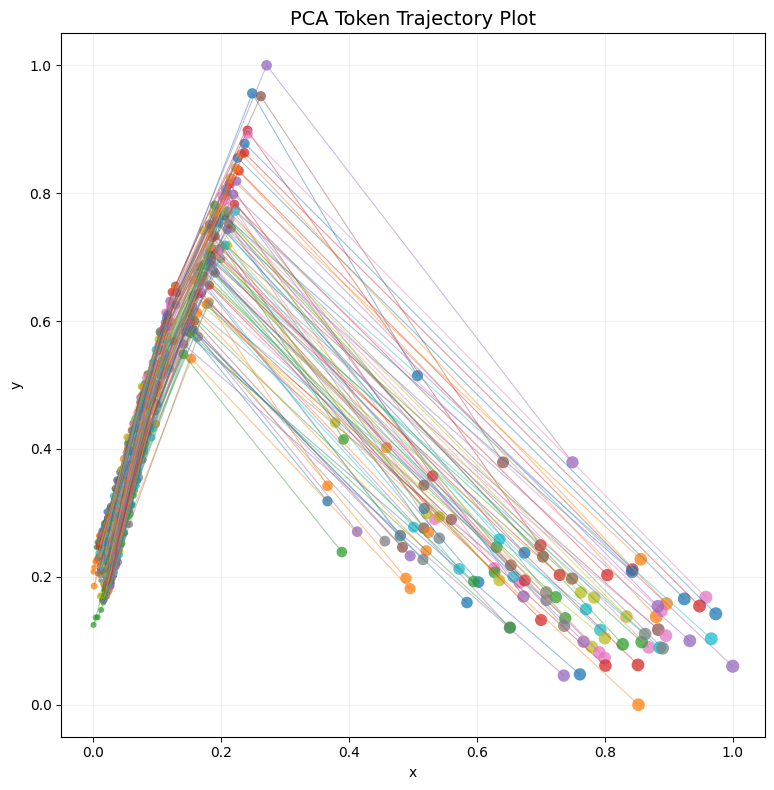

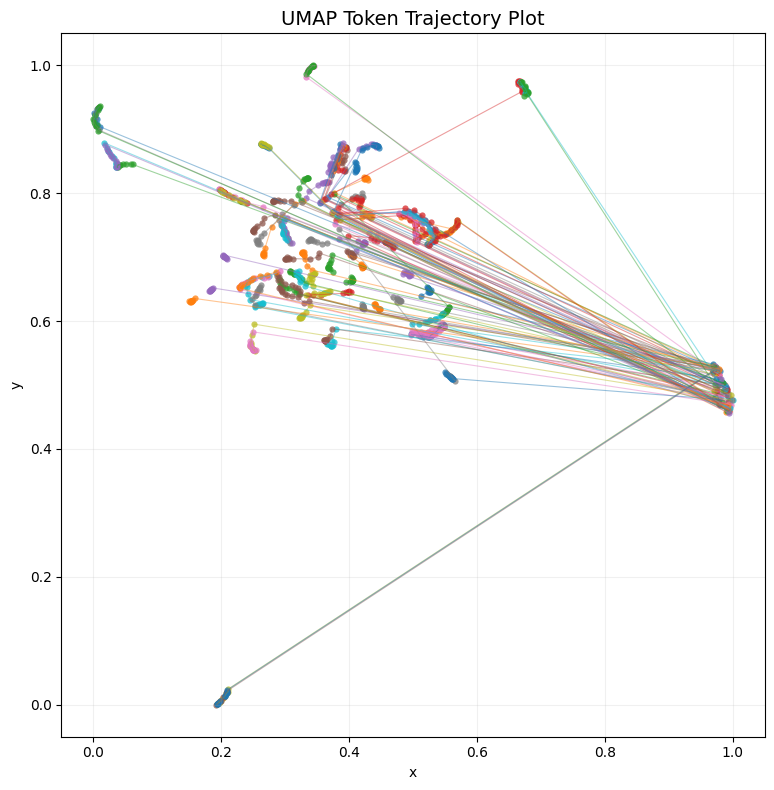

In [14]:
render_reference_plots(pca_jump, umap_density)

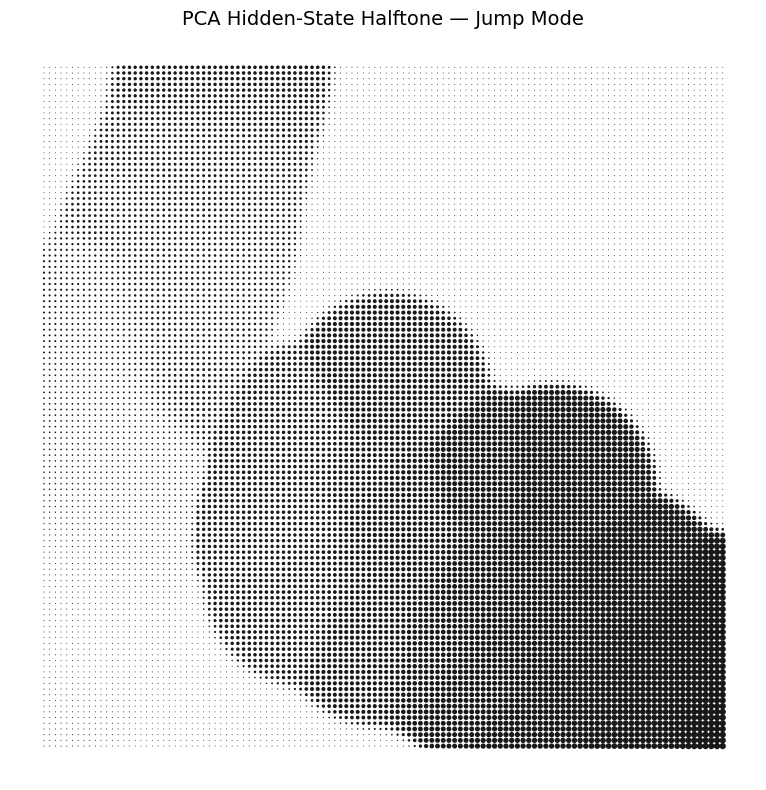

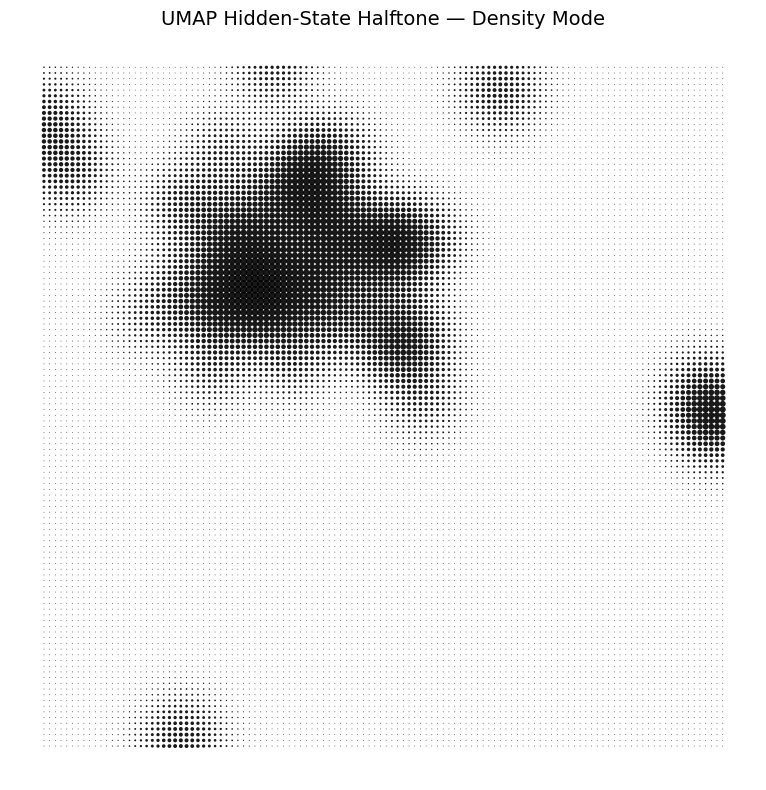

In [15]:
render_halftone_field(
    pca_jump,
    title="PCA Hidden-State Halftone — Jump Mode",
    weight_key="jump",
    grid_n=120,
    influence=0.025,
    min_size=0.45,
    max_size=20,
    power=1.15
)

render_halftone_field(
    umap_density,
    title="UMAP Hidden-State Halftone — Density Mode",
    weight_key=None,
    grid_n=120,
    influence=0.038,
    min_size=0.35,
    max_size=30,
    power=1.05
)

## Directional halftone renderer

In [16]:
from matplotlib.patches import Ellipse

def add_pca_tangent_direction(data: dict) -> dict:
    lookup = {
        (p["token_index"], p["layer"]): p
        for p in data["points"]
    }

    points = []

    for p in data["points"]:
        token_index = p["token_index"]
        layer = p["layer"]

        prev = lookup.get((token_index, layer - 1))
        next_p = lookup.get((token_index, layer + 1))

        if prev is not None and next_p is not None:
            dx = next_p["x"] - prev["x"]
            dy = next_p["y"] - prev["y"]
        elif prev is not None:
            dx = p["x"] - prev["x"]
            dy = p["y"] - prev["y"]
        elif next_p is not None:
            dx = next_p["x"] - p["x"]
            dy = next_p["y"] - p["y"]
        else:
            dx, dy = 0.0, 0.0

        angle = float(np.arctan2(dy, dx))

        points.append({
            **p,
            "tangent_dx": float(dx),
            "tangent_dy": float(dy),
            "angle": angle,
            "angle_degrees": float(np.degrees(angle))
        })

    result = {
        "tokens": data["tokens"],
        "points": points
    }

    if "explained_variance" in data:
        result["explained_variance"] = data["explained_variance"]

    return result

def render_pca_direction_halftone(
    data: dict,
    title: str = "PCA Hidden-State Halftone — Jump Direction Mode",
    grid_n: int = 70,
    influence: float = 0.03,
    min_size: float = 0.002,
    max_size: float = 0.018,
    aspect: float = 0.45,
    power: float = 1.1
):
    coords = np.array([
        [p["x"], p["y"]]
        for p in data["points"]
    ])

    jumps = np.array([
        p.get("jump", 0.0)
        for p in data["points"]
    ])

    angles = np.array([
        p.get("angle", 0.0)
        for p in data["points"]
    ])

    grid = np.linspace(0, 1, grid_n)

    fig, ax = plt.subplots(figsize=(8, 8))

    for x in grid:
        for y in grid:
            dist_sq = np.sum((coords - np.array([x, y])) ** 2, axis=1)
            kernel = np.exp(-dist_sq / (2 * influence ** 2))

            tone = np.sum(jumps * kernel) / (np.sum(kernel) + 1e-8)

            sin_avg = np.sum(np.sin(angles) * jumps * kernel)
            cos_avg = np.sum(np.cos(angles) * jumps * kernel)
            angle = np.degrees(np.arctan2(sin_avg, cos_avg))

            width = min_size + (tone ** power) * max_size
            height = width * aspect

            dot = Ellipse(
                (x, y),
                width=width,
                height=height,
                angle=angle,
                facecolor="black",
                edgecolor="none",
                alpha=0.9
            )

            ax.add_patch(dot)

    ax.set_title(title, fontsize=14)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal", adjustable="box")
    ax.axis("off")
    plt.tight_layout()
    plt.show()


pca_direction = add_pca_tangent_direction(pca_jump)

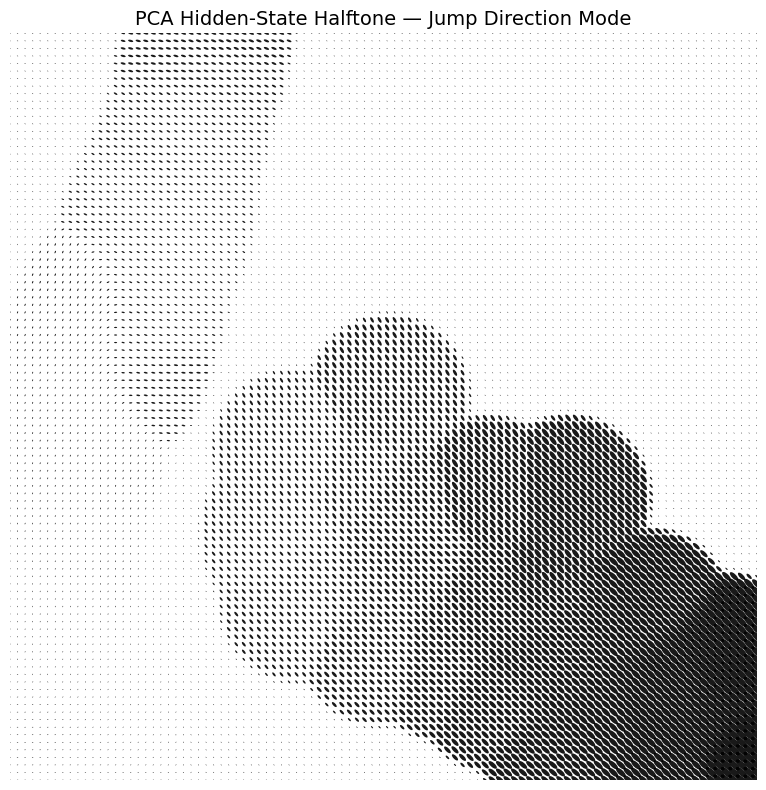

In [17]:
render_pca_direction_halftone(
    pca_direction,
    grid_n=100,
    influence=0.018,
    min_size=0.0018,
    max_size=0.018,
    aspect=0.41,
    power=1.15
)

## Raw values
Note that token_index is used as a reading/order reference. It is not an internal model value (not the token ID in transformer models).

In [18]:
print("PCA jump / direction values")
print("token_index, token, layer, x, y, jump, raw_jump, angle_degrees")

for point in pca_direction["points"]:
    print(
        point["token_index"],
        repr(point["token_str"]),
        point["layer"],
        round(point["x"], 6),
        round(point["y"], 6),
        round(point["jump"], 6),
        round(point["raw_jump"], 6),
        round(np.degrees(point["angle"]), 2),
        sep=", "
    )

PCA jump / direction values
token_index, token, layer, x, y, jump, raw_jump, angle_degrees
1, 'in', 0, 0.015143, 0.279644, 0.0, 0.0, -107.65
2, ' Just', 0, 0.017939, 0.281569, 0.0, 0.0, -117.11
3, '-', 0, 0.013734, 0.263896, 0.0, 0.0, -126.42
4, ' spring', 0, 0.014064, 0.264789, 0.0, 0.0, -113.2
5, ' when', 0, 0.01622, 0.274842, 0.0, 0.0, -114.43
6, ' the', 0, 0.016538, 0.272317, 0.0, 0.0, -114.27
7, ' world', 0, 0.015905, 0.26755, 0.0, 0.0, -107.07
8, ' is', 0, 0.017326, 0.264318, 0.0, 0.0, -110.24
9, ' mud', 0, 0.015558, 0.263664, 0.0, 0.0, -100.28
10, '-', 0, 0.013605, 0.252839, 0.0, 0.0, -109.92
11, ' l', 0, 0.010789, 0.242446, 0.0, 0.0, -143.68
12, 'us', 0, 0.009511, 0.239078, 0.0, 0.0, -111.8
13, 'cious', 0, 0.011844, 0.234834, 0.0, 0.0, -122.23
14, ' the', 0, 0.015548, 0.255352, 0.0, 0.0, -106.13
15, ' little', 0, 0.013574, 0.243833, 0.0, 0.0, -110.21
16, ' lame', 0, 0.012275, 0.24632, 0.0, 0.0, 18.66
17, ' balloon', 0, 0.011878, 0.238898, 0.0, 0.0, -90.21
18, 'man', 0, 0.012317

In [19]:
print("UMAP density values")
print("token_index, token, layer, x, y, density, raw_density")

for point in umap_density["points"]:
    print(
        point["token_index"],
        repr(point["token_str"]),
        point["layer"],
        round(point["x"], 6),
        round(point["y"], 6),
        round(point["density"], 6),
        round(point["raw_density"], 6),
        sep=", "
    )

UMAP density values
token_index, token, layer, x, y, density, raw_density
1, 'in', 0, 0.410128, 0.835492, 0.65784, 218.26959
2, ' Just', 0, 0.424685, 0.823257, 0.687365, 226.625368
3, '-', 0, 0.545709, 0.611002, 0.39807, 144.753608
4, ' spring', 0, 0.667489, 0.97521, 0.000134, 32.136081
5, ' when', 0, 0.442874, 0.871913, 0.412775, 148.915339
6, ' the', 0, 0.394011, 0.835136, 0.675943, 223.392959
7, ' world', 0, 0.345318, 0.999024, 0.037883, 42.819022
8, ' is', 0, 0.419764, 0.800385, 0.790022, 255.677789
9, ' mud', 0, 0.322792, 0.606982, 0.650356, 216.151623
10, '-', 0, 0.546496, 0.612225, 0.397916, 144.710007
11, ' l', 0, 0.522676, 0.65362, 0.556674, 189.639245
12, 'us', 0, 0.329958, 0.708044, 0.986227, 311.204764
13, 'cious', 0, 0.307255, 0.678082, 0.923831, 293.54644
14, ' the', 0, 0.391965, 0.83542, 0.675729, 223.332338
15, ' little', 0, 0.368145, 0.817276, 0.754984, 245.761748
16, ' lame', 0, 0.281257, 0.786468, 0.67596, 223.397702
17, ' balloon', 0, 0.196337, 0.807298, 0.270635, 1